In [1]:
import sys
sys.path.append('../')
import karman
import pandas as pd

In [2]:
karman_dataset=karman.KarmanDataset(thermo_path='../data/satellites_data_w_sw.csv',
                            min_date=pd.to_datetime("2000-07-29 00:59:47"),
                            max_date=pd.to_datetime("2024-05-31 23:59:32"),
                            normalization_dict=None,
                            #omni_path='omniweb_1min_data_2001_2022.h5',
                           )

Creating thermospheric density dataset
Used features: Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'celestrack__ap_average__',
       'space_environment_technologies__f107_obs__',
       'space_environment_technologies__f107_average__',
       'space_environment_technologies__s107_obs__',
       'space_environment_technologies__s107_average__',
       'space_environment_technologies__m107_obs__',
       'space_environment_technologies__m107_average__',
       'space_environment_technologies__y107_obs__',
       'space_environment_technologies__y107_average__', 'JB08__d_st_dt__[K]',
       'tudelft_thermo__longitude__[deg]_sin',
       'tudelft_thermo__longitude__[deg]_cos', 'all__day_of_year__[d]_sin',
       'all__day_of_year__[d]_cos', 'all__seconds_in_day__[s]_sin',
       'all__seconds_in_day__[s]_cos'],
      dtype='object')
Index(['tudelft_thermo__altitude__[m]', 'tudelft_thermo__latitude__[deg]',
       'celestrack__ap_average__',
       'spa

array([[<Axes: title={'center': 'all__dates_datetime__'}>,
        <Axes: title={'center': 'tudelft_thermo__altitude__[m]'}>,
        <Axes: title={'center': 'tudelft_thermo__longitude__[deg]'}>,
        <Axes: title={'center': 'tudelft_thermo__latitude__[deg]'}>,
        <Axes: title={'center': 'tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]'}>],
       [<Axes: title={'center': 'all__year__[y]'}>,
        <Axes: title={'center': 'all__day_of_year__[d]'}>,
        <Axes: title={'center': 'all__seconds_in_day__[s]'}>,
        <Axes: title={'center': 'celestrack__ap_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__f107_obs__'}>],
       [<Axes: title={'center': 'space_environment_technologies__f107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_obs__'}>,
        <Axes: title={'center': 'space_environment_technologies__s107_average__'}>,
        <Axes: title={'center': 'space_environment_technologies__m107_o

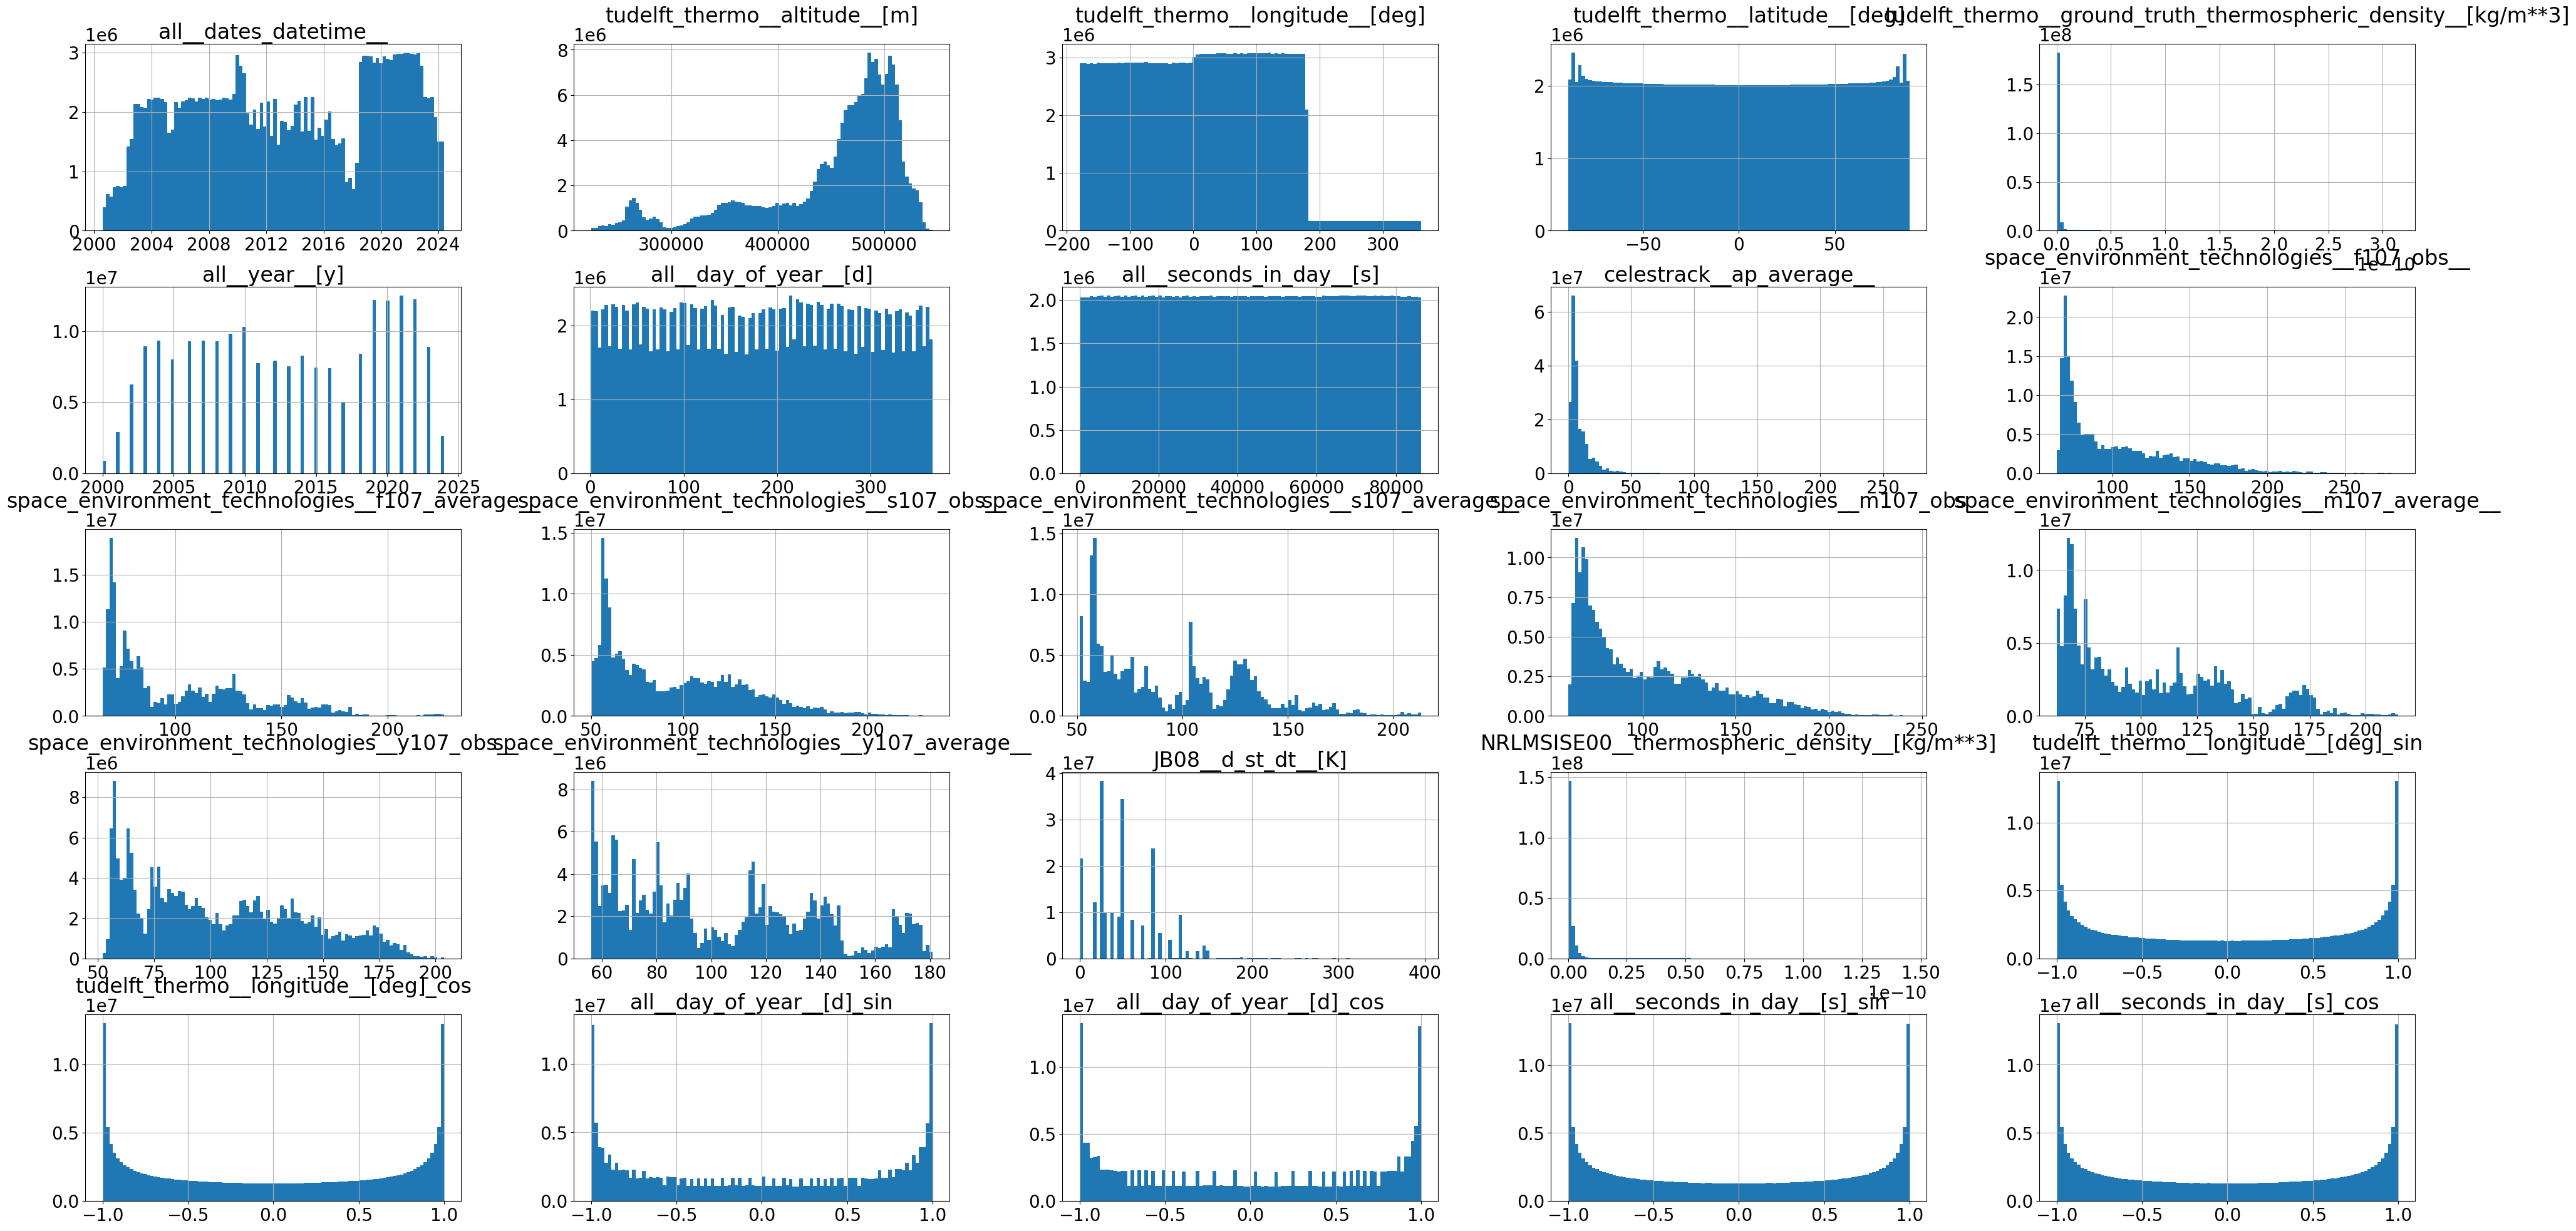

In [33]:
import matplotlib.pyplot as plt
karman_dataset.data_thermo['data'].hist(figsize=(48,24),bins=100)

In [7]:
dates=pd.to_datetime(karman_dataset.data_thermo['data']['all__dates_datetime__'])

In [20]:
start_date=pd.to_datetime("2024-05-10 00:01:00")
end_date=pd.to_datetime("2024-05-13 00:01:00")
subset=karman_dataset.data_thermo['data'].iloc[dates[(dates>start_date) & (dates<end_date)].index]

In [17]:
subset['tudelft_thermo__satellite__'].unique()

array(['grace_c', 'swarm_a', 'swarm_c', 'swarm_b'], dtype=object)

Text(0, 0.5, 'density [kg/m^3]')

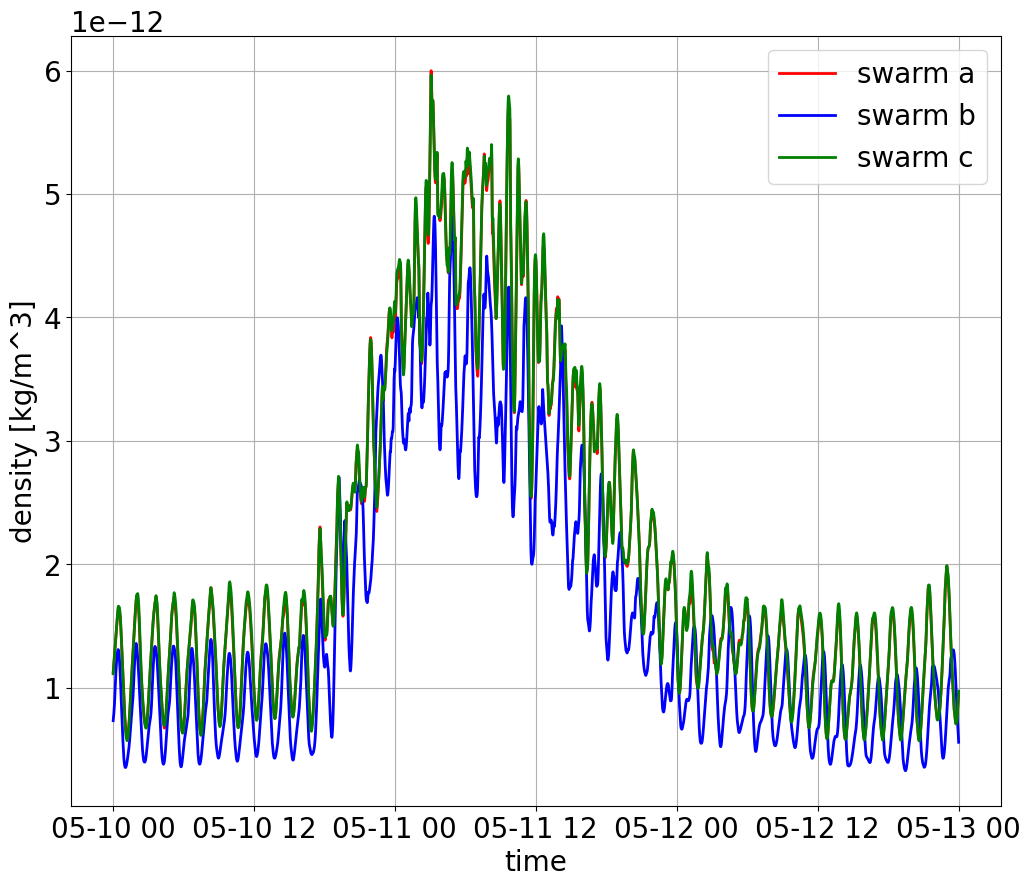

In [29]:
import matplotlib.pyplot as plt
import matplotlib
#set fontsize
matplotlib.rcParams.update({'font.size': 20})
plt.figure(figsize=(12,10))
mask=subset['tudelft_thermo__satellite__']=='swarm_a'
plt.plot(subset['all__dates_datetime__'][mask].values, 
         (subset['tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]'][mask].values),color='red',label='swarm a',linewidth=2)
mask=subset['tudelft_thermo__satellite__']=='swarm_b'
plt.plot(subset['all__dates_datetime__'][mask].values, 
         (subset['tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]'][mask].values),color='blue',label='swarm b',linewidth=2)
mask=subset['tudelft_thermo__satellite__']=='swarm_c'
plt.plot(subset['all__dates_datetime__'][mask].values, 
         (subset['tudelft_thermo__ground_truth_thermospheric_density__[kg/m**3]'][mask].values),color='green',label='swarm c',linewidth=2)
plt.legend(fontsize=20,loc='upper right')
plt.grid()
plt.xlabel('time')
plt.ylabel('density [kg/m^3]')